# Importing the libraries

In [2]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

# for getting summary info on models
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Downloading the dataset

In [3]:
import torchvision
import torchvision.transforms as transforms

# Define transformations for the dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load the training data
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Download and load the test data
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
batch_size = 64 # You can adjust this batch size as needed
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"CIFAR-10 training dataset size: {len(train_dataset)}")
print(f"CIFAR-10 test dataset size: {len(test_dataset)}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")


100%|██████████| 170M/170M [27:41<00:00, 103kB/s] 


CIFAR-10 training dataset size: 50000
CIFAR-10 test dataset size: 10000
Number of training batches: 782
Number of test batches: 157


In [4]:
from torch.utils.data import Subset # Import Subset

# Step 1: Reduce dataset size to reduce computational time
train_indices = np.random.choice(len(train_dataset), 20000, replace=False)
test_indices  = np.random.choice(len(test_dataset),  4000,  replace=False)

train_dataset = Subset(train_dataset, train_indices)
test_dataset  = Subset(test_dataset,  test_indices)

# Step 2: Convert datasets to tensors (mirrors dataNorm + labelsT)
# Stack all images and labels into tensors
train_data_T = torch.stack([img for img, _ in train_dataset])
train_labels_T = torch.tensor([label for _, label in train_dataset])

test_data_T = torch.stack([img for img, _ in test_dataset])
test_labels_T = torch.tensor([label for _, label in test_dataset])

# Step 3: Convert into PyTorch Datasets (TensorDataset, mirrors original)
train_data = TensorDataset(train_data_T, train_labels_T)
test_data = TensorDataset(test_data_T, test_labels_T)

# Step 4: Translate into DataLoader objects
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])


print(f"Training batches per epoch: {len(train_loader)}")
print(f"Test batches per epoch: {len(test_loader)}")

Training batches per epoch: 625
Test batches per epoch: 1


# Creating the model

In [5]:
from torch.nn.modules import loss
def create_model(printtoggle=False):

  class Net(nn.Module):
    def __init__(self,printtoggle):
      super().__init__()

      # convolution layers
      self.conv1 = nn.Conv2d(3,32,kernel_size=3,stride=1,padding=1)
      self.conv2 = nn.Conv2d(32,64,kernel_size=3,stride=1,padding=1)
      self.conv3 = nn.Conv2d(64,128,kernel_size=3,stride=1,padding=1)

      expectSize = 2048

      # fully connected layer

      self.fc1 = nn.Linear(expectSize,1024)
      self.fc2 = nn.Linear(1024,512)
      self.fc3 = nn.Linear(512,10)

      # define dropout
      self.drop = nn.Dropout(p=0.5)

      # toggle for printing out tensor sizes during forward prop
      self.print = printtoggle

    def forward(self,x):
      x = F.relu(F.max_pool2d(self.conv1(x),2))
      if self.print: print(f"conv1: {x.shape}")
      x = F.relu(F.max_pool2d(self.conv2(x),2))
      if self.print: print(f"conv2: {x.shape}")
      x = F.relu(F.max_pool2d(self.conv3(x),2))
      if self.print: print(f"conv3: {x.shape}")

      x = x.view(x.size(0),-1)
      if self.print: print(f"view: {x.shape}")
      x = F.relu(self.fc1(x))
      x = self.drop(x)
      if self.print: print(f"fc1: {x.shape}")
      x = F.relu(self.fc2(x))
      x = self.drop(x)
      if self.print: print(f"fc2: {x.shape}")
      x = self.fc3(x)
      if self.print: print(f"fc3: {x.shape}")
      return x

  net = Net(printtoggle=True)
  lossfun = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(net.parameters(),lr=0.001)
  return net,lossfun,optimizer

# Training the model

In [19]:
def TrainTheModel():

  numepochs = 20

  # create a new model
  net,lossfun,optimizer = create_model()

  # intialize losses
  losses = torch.zeros(numepochs)
  trainAcc = []
  testAcc = []

  # loop for epochs
  for epochi in range(numepochs):

    net.train()
    batchAcc = []
    batchLoss = []

    for X,y in train_loader:

      # forward prop
      yHat = net(X)

      # calc loss
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # calc accuracy
      matches = torch.argmax(yHat,axis=1) == y
      matchesNumeric = matches.float()
      accuracyPct = 100*torch.mean(matchesNumeric)
      batchAcc.append(accuracyPct.item())

    # Since we have trained through the batches, we want to get the average training accuracy
    trainAcc.append(np.mean(batchAcc))

    # and calculate average losses
    losses[epochi] = np.mean(batchLoss)

    # then we will test the accuracy

    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # turn off autograd
      yHat = net(X)

    testAcc.append(100*torch.mean((torch.argmax(yHat,axis=1)==y).float()).item())

  return losses,trainAcc,testAcc,net

In [20]:
losses, trainAcc, testAcc, net = TrainTheModel()

print(f"trainAcc first value: {trainAcc[0]:.2f}")   # should NOT be 0
print(f"testAcc first value:  {testAcc[0]:.2f}")    # should NOT be 0
print(f"trainAcc last value:  {trainAcc[-1]:.2f}")
print(f"testAcc last value:   {testAcc[-1]:.2f}")

Streaming output truncated to the last 5000 lines.
conv3: torch.Size([32, 128, 4, 4])
view: torch.Size([32, 2048])
fc1: torch.Size([32, 1024])
fc2: torch.Size([32, 512])
fc3: torch.Size([32, 10])
conv1: torch.Size([32, 32, 16, 16])
conv2: torch.Size([32, 64, 8, 8])
conv3: torch.Size([32, 128, 4, 4])
view: torch.Size([32, 2048])
fc1: torch.Size([32, 1024])
fc2: torch.Size([32, 512])
fc3: torch.Size([32, 10])
conv1: torch.Size([32, 32, 16, 16])
conv2: torch.Size([32, 64, 8, 8])
conv3: torch.Size([32, 128, 4, 4])
view: torch.Size([32, 2048])
fc1: torch.Size([32, 1024])
fc2: torch.Size([32, 512])
fc3: torch.Size([32, 10])
conv1: torch.Size([32, 32, 16, 16])
conv2: torch.Size([32, 64, 8, 8])
conv3: torch.Size([32, 128, 4, 4])
view: torch.Size([32, 2048])
fc1: torch.Size([32, 1024])
fc2: torch.Size([32, 512])
fc3: torch.Size([32, 10])
conv1: torch.Size([32, 32, 16, 16])
conv2: torch.Size([32, 64, 8, 8])
conv3: torch.Size([32, 128, 4, 4])
view: torch.Size([32, 2048])
fc1: torch.Size([32, 1024

# Evaluating the model

/tmp/ipykernel_542/3561043231.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax2.plot(test_acc_data, 'o-', label='Test Acc', color='darkblue', linestyle='--') # Added markers 'o-' and changed color/linestyle


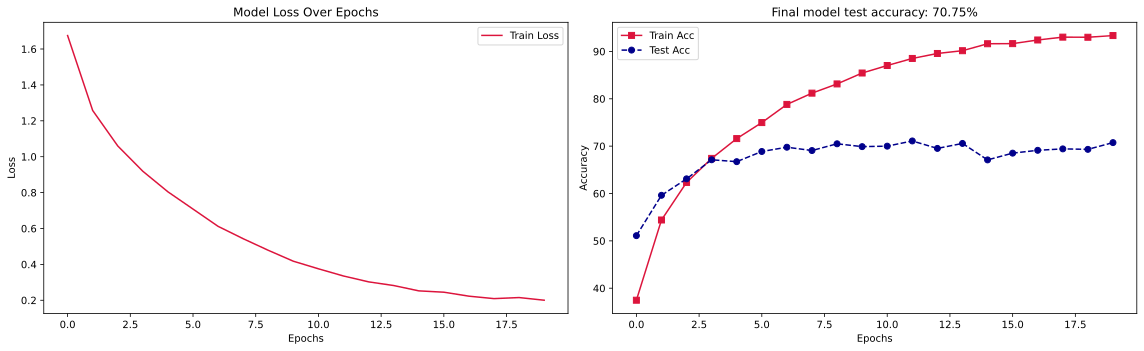

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_training_history(losses_data, train_acc_data, test_acc_data):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5)) # Adjusted figure size for better readability

    # Loss Plot
    ax1.plot(losses_data, label='Train Loss', color='crimson')
    ax1.set_title('Model Loss Over Epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy Plot
    ax2.plot(train_acc_data, 's-', label='Train Acc', color='crimson') # Added markers 's-' as in previous version
    ax2.plot(test_acc_data, 'o-', label='Test Acc', color='darkblue', linestyle='--') # Added markers 'o-' and changed color/linestyle
    ax2.set_title(f'Final model test accuracy: {test_acc_data[-1]:.2f}%') # Display final test accuracy
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

# Call the function with the actual data obtained from training
plot_training_history(losses, trainAcc, testAcc)

conv1: torch.Size([1, 32, 16, 16])
conv2: torch.Size([1, 64, 8, 8])
conv3: torch.Size([1, 128, 4, 4])
view: torch.Size([1, 2048])
fc1: torch.Size([1, 1024])
fc2: torch.Size([1, 512])
fc3: torch.Size([1, 10])
conv1: torch.Size([1, 32, 16, 16])
conv2: torch.Size([1, 64, 8, 8])
conv3: torch.Size([1, 128, 4, 4])
view: torch.Size([1, 2048])
fc1: torch.Size([1, 1024])
fc2: torch.Size([1, 512])
fc3: torch.Size([1, 10])
conv1: torch.Size([1, 32, 16, 16])
conv2: torch.Size([1, 64, 8, 8])
conv3: torch.Size([1, 128, 4, 4])
view: torch.Size([1, 2048])
fc1: torch.Size([1, 1024])
fc2: torch.Size([1, 512])
fc3: torch.Size([1, 10])
conv1: torch.Size([1, 32, 16, 16])
conv2: torch.Size([1, 64, 8, 8])
conv3: torch.Size([1, 128, 4, 4])
view: torch.Size([1, 2048])
fc1: torch.Size([1, 1024])
fc2: torch.Size([1, 512])
fc3: torch.Size([1, 10])
conv1: torch.Size([1, 32, 16, 16])
conv2: torch.Size([1, 64, 8, 8])
conv3: torch.Size([1, 128, 4, 4])
view: torch.Size([1, 2048])
fc1: torch.Size([1, 1024])
fc2: torch.

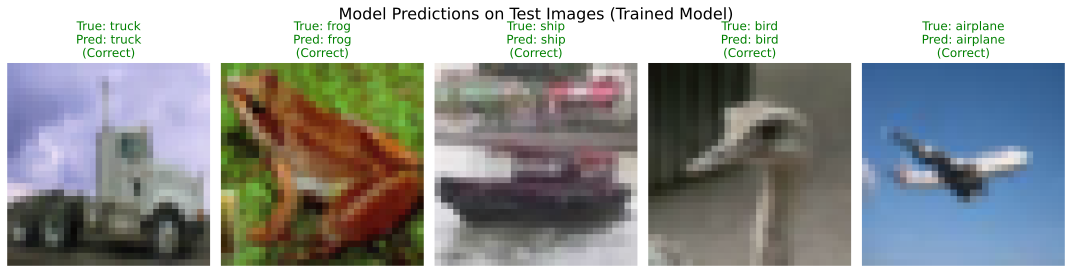

In [22]:
# Set the model to evaluation mode
net.eval()

# Get class names from the dataset robustly
# The test_dataset is a Subset object, which wraps the original CIFAR10 dataset.
# We need to find the base CIFAR10 dataset to get the 'classes' attribute.
current_dataset = test_dataset
while hasattr(current_dataset, 'dataset') and not isinstance(current_dataset, torchvision.datasets.CIFAR10):
    current_dataset = current_dataset.dataset
class_names = current_dataset.classes

# Select 5 random indices from the test dataset
random_indices = random.sample(range(len(test_dataset)), 5)

fig, axs = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle('Model Predictions on Test Images (Trained Model)', fontsize=16)

for i, idx in enumerate(random_indices):
    # Get image and label from the test_dataset
    image, true_label = test_dataset[idx]

    # Add a batch dimension (C, H, W) -> (1, C, H, W) for the model input
    image_input = image.unsqueeze(0)

    # Make a prediction (no_grad since we're not training)
    with torch.no_grad():
        outputs = net(image_input)

    # Get the predicted class
    _, predicted_label = torch.max(outputs.data, 1)
    predicted_label = predicted_label.item()

    # Denormalize the image for plotting
    # Original normalization was (0.5, 0.5, 0.5) for mean and std
    # Image = (Image * std) + mean
    plot_image = image.numpy().transpose((1, 2, 0)) # Convert from (C, H, W) to (H, W, C)
    plot_image = plot_image * 0.5 + 0.5 # Denormalize to [0, 1]
    plot_image = np.clip(plot_image, 0, 1) # Clip to ensure valid pixel values

    # Plot the image
    axs[i].imshow(plot_image)
    axs[i].axis('off')

    # Set title with true and predicted labels
    is_correct = "Correct" if predicted_label == true_label else "Wrong"
    color = "green" if predicted_label == true_label else "red"
    axs[i].set_title(f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}\n({is_correct})", color=color)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Confusion Matrix

conv1: torch.Size([4000, 32, 16, 16])
conv2: torch.Size([4000, 64, 8, 8])
conv3: torch.Size([4000, 128, 4, 4])
view: torch.Size([4000, 2048])
fc1: torch.Size([4000, 1024])
fc2: torch.Size([4000, 512])
fc3: torch.Size([4000, 10])
              precision    recall  f1-score   support

    airplane       0.78      0.76      0.77       393
  automobile       0.85      0.86      0.85       400
        bird       0.56      0.57      0.57       383
         cat       0.53      0.44      0.48       400
        deer       0.59      0.68      0.63       412
         dog       0.60      0.64      0.62       389
        frog       0.75      0.79      0.77       406
       horse       0.74      0.71      0.73       413
        ship       0.86      0.83      0.85       402
       truck       0.81      0.79      0.80       402

    accuracy                           0.71      4000
   macro avg       0.71      0.71      0.71      4000
weighted avg       0.71      0.71      0.71      4000



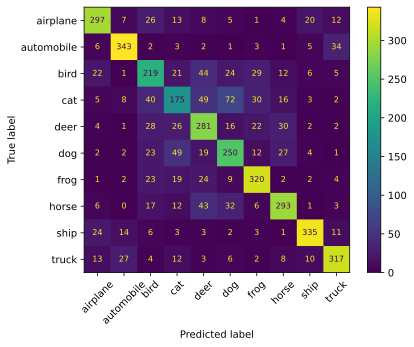

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
net.eval()
with torch.no_grad():
  X,y_true = next(iter(test_loader))
  yHat = net(X)
  y_pred = torch.argmax(yHat,axis=1)

y_true = y_true.numpy()
y_pred = y_pred.numpy()
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']
cm = confusion_matrix(y_true,y_pred)
ConfusionMatrixDisplay(cm,display_labels=class_names).plot(text_kw={'fontsize': 8}, xticks_rotation=45)
print(classification_report(y_true, y_pred, target_names=classes))

### Takeaway from the confusion matrix

The highest is score is 400.

Categories with the highest scores are:
automobile,frog, and ship.

We can clearly see that cat has been confused with dog and dear with horse many times.

# Saving the model

In [24]:
import torch

# Define a path to save the model
model_path = 'cifar10_cnn_model.pth'

# Save the model's state dictionary
torch.save(net.state_dict(), model_path)

print(f"Model saved to {model_path}")

Model saved to cifar10_cnn_model.pth
